<center><h1>Job Sheet Data Science Project</h1></center>

# 1. Business Understanding

## 1.1. Business Objectives

### 1.1.1. Background

Sebuah Perusahaan Real Estate di Amerika Serikat, ingin mengoptimalkan strategi penentuan harga properti untuk memperkuat daya saing dan memaksimalkan profitabilitas. Menyadari tingginya pengaruh data dalam penetapan harga properti yang kompetitif, perusahaan membutuhkan model prediksi yang akurat dan berbasis data untuk memperkirakan harga properti dengan mempertimbangkan berbagai faktor seperti lokasi, ukuran bangunan, dan kualitas lingkungan.

### 1.1.2. Business Objectives

Target yang ingin dicapai dari proyek ini adalah:




1. Menghasilkan model prediktif harga properti yang akurat untuk mendukung strategi penetapan harga perusahaan dalam pasar yang dinamis.
2. Memberikan wawasan bagi tim penjualan dan pemasaran mengenai faktor-faktor kunci yang mempengaruhi harga, seperti lokasi, ukuran properti, dan kondisi lingkungan.
3. Mendukung keputusan investasi melalui pemahaman yang lebih baik atas tren harga pasar di berbagai wilayah Amerika Serikat.

### 1.1.3. Business Success Criteria

Kriteria sukses dari target yang ingin dicapai adalah:

1. Memiliki RMSE (Root Mean Squared Error) rendah, sebagai tolok ukur utama akurasi model.
2. Memiliki MAE yang rendah agar semakin dekat prediksi model dengan nilai sebenarnya, yang berarti model lebih akurat.
2. Mencapai R-Squared tinggi, menunjukkan bahwa model dapat menjelaskan sebagian besar variasi dalam harga properti.
3. Model yang dibangun harus efisien dan mudah diintegrasikan dalam sistem bisnis perusahaan agar dapat digunakan dalam berbagai skenario pasar.



## 1.2. Data Science Goals

### 1.2.1. Data Science Goals

Tujuan dari proyek data science ini adalah:

1. Mengidentifikasi faktor-faktor utama yang berkontribusi pada variasi harga properti di pasar Amerika Serikat.
2. Membangun model machine learning yang dapat diandalkan untuk memprediksi harga properti, dengan mempertimbangkan berbagai fitur yang tersedia dalam dataset.



### 1.2.2. Data Science Success Criteria

Kriteria kesuksesan proyek data science ini adalah:

1. Model prediksi memiliki RMSE rendah, MAE rendah, dan R-Squared tinggi, menunjukkan keakuratan dan keandalan model dalam memprediksi harga.
2. Analisis dan visualisasi data memberikan insight yang jelas dan dapat digunakan mengenai faktor-faktor yang mempengaruhi harga properti, sehingga mendukung strategi bisnis dan pemasaran perusahaan.

# 2. Data Understanding

## 2.1. Data Collection

**Import data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
train_data = pd.read_csv('/content/drive/MyDrive/smt7/uts/train_data.csv', encoding='ISO-8859-1')
public_test_data = pd.read_csv('/content/drive/MyDrive/smt7/uts/public_test_data.csv', encoding='ISO-8859-1')

## 2.2. Data Description

**Dataset information**

In [ ]:
print("Struktur data train_data:")
print(train_data.info())
print("\nStruktur data public_test_data:")
print(public_test_data.info())

Struktur data train_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2944 entries, 0 to 2943
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       2944 non-null   int64  
 1   bathrooms      2944 non-null   float64
 2   sqft_living    2944 non-null   int64  
 3   sqft_lot       2944 non-null   int64  
 4   floors         2944 non-null   float64
 5   waterfront     2944 non-null   int64  
 6   view           2944 non-null   int64  
 7   condition      2944 non-null   int64  
 8   sqft_above     2944 non-null   int64  
 9   sqft_basement  2944 non-null   int64  
 10  yr_built       2944 non-null   int64  
 11  yr_renovated   2944 non-null   int64  
 12  street         2944 non-null   object 
 13  city           2944 non-null   object 
 14  statezip       2944 non-null   object 
 15  price          2944 non-null   float64
dtypes: float64(3), int64(10), object(3)
memory usage: 368.1+ KB
None

Stru

Kedua dataset tidak memiliki nilai null di seluruh kolom, sehingga tidak diperlukan penanganan missing values.

Statistik deskriptif untuk train_data

In [ ]:
print("Statistik Deskriptif train_data:")
print(train_data.describe())

Statistik Deskriptif train_data:
          bedrooms    bathrooms   sqft_living      sqft_lot       floors  \
count  2944.000000  2944.000000   2944.000000  2.944000e+03  2944.000000   
mean      3.398438     2.153787   2141.204144  1.447538e+04     1.510530   
std       0.905984     0.785813    962.695894  3.635410e+04     0.536843   
min       0.000000     0.000000    370.000000  7.040000e+02     1.000000   
25%       3.000000     1.750000   1460.000000  5.000000e+03     1.000000   
50%       3.000000     2.250000   1980.000000  7.642000e+03     1.500000   
75%       4.000000     2.500000   2620.000000  1.103650e+04     2.000000   
max       9.000000     6.750000  10040.000000  1.074218e+06     3.500000   

        waterfront         view    condition   sqft_above  sqft_basement  \
count  2944.000000  2944.000000  2944.000000  2944.000000    2944.000000   
mean      0.006454     0.238111     3.454144  1825.582201     315.621943   
std       0.080090     0.769819     0.678240   864.020

Terdiri dari 2.944 data rumah dengan rata-rata memiliki 3 kamar tidur dan 2 kamar mandi, tapi ada rumah yang tidak memiliki kamar tidur ataupun kamar mandi dan ini harus dicek lebih lanjut. Luas bangunan bervariasi dari 370 sqft (rumah kecil) hingga 10.040 sqft (rumah mewah), dengan rata-rata 2.141 sqft. Luas tanah rata-rata 14.475 sqft, tetapi ada yang mencapai lebih dari 1 juta sqft.

Sebagian besar rumah dibangun pada tahun 1970-an, dengan kondisi yang cukup baik (rata-rata nilai 3 dari skala 1-5). Harga rumah berkisar dari USD 0 (data tidak masuk akal) hingga USD 7.000.000, dengan rata-rata USD 547.000. Hanya sedikit rumah yang punya akses ke perairan atau pemandangan.

Secara umum, dataset ini cukup bervariasi, tetapi ada data yang tidak wajar seperti harga USD 0 yang perlu diperbaiki.

Statistik deskriptif untuk public_test_data

In [ ]:
print("Statistik Deskriptif public_test_data:")
print(public_test_data.describe())

Statistik Deskriptif public_test_data:
         bedrooms   bathrooms  sqft_living       sqft_lot      floors  \
count  736.000000  736.000000   736.000000     736.000000  736.000000   
mean     3.407609    2.167799  2124.429348   16173.156250    1.501359   
std      0.900278    0.765788   911.017256   35172.073581    0.534521   
min      1.000000    0.750000   550.000000     638.000000    1.000000   
25%      3.000000    1.750000  1480.000000    5272.500000    1.000000   
50%      3.000000    2.250000  1975.000000    7800.000000    1.500000   
75%      4.000000    2.500000  2600.000000   11465.500000    2.000000   
max      7.000000    5.750000  7320.000000  435600.000000    3.000000   

       waterfront        view   condition   sqft_above  sqft_basement  \
count  736.000000  736.000000  736.000000   736.000000     736.000000   
mean     0.012228    0.228261    3.459239  1826.576087     297.853261   
std      0.109978    0.771651    0.682908   830.130967     453.366633   
min      0.

Rata-rata rumah memiliki 3 kamar tidur dan 2 kamar mandi, dengan luas bangunan sekitar 2.124 sqft. Ukuran lahan bervariasi sangat besar, mulai dari 638 sqft hingga 435.600 sqft, meskipun sebagian besar berada di kisaran antara 5.272 sqft dan 11.465 sqft. Sebagian besar rumah ini memiliki 1 hingga 2 lantai, dengan rata-rata 1,5 lantai, menunjukkan bahwa properti di dataset ini lebih sering merupakan bangunan rendah.

Dalam hal fasilitas, properti dengan akses ke tepi air hanya 1,2%, dan sebagian besar tidak memiliki pemandangan khusus (nilai median untuk view adalah 0). Kondisi rumah secara keseluruhan memiliki rata-rata nilai 3,46 dari 5, menunjukkan bahwa rumah-rumah ini berada dalam kondisi baik atau cukup terawat. Luas bangunan di atas tanah (sqft_above) rata-rata mencapai 1.826 sqft, sedangkan ruang bawah tanah (basement) memiliki rata-rata luas 297 sqft, dengan banyak properti yang tidak memiliki basement sama sekali (nilai median 0).

Untuk tahun pembuatan, rumah-rumah ini mayoritas dibangun pada tahun 1972, dan sebagian besar tidak direnovasi, yang terlihat dari nilai median yr_renovated yang tetap 0. Harga properti dalam dataset ini sangat bervariasi, mulai dari USD 0 hingga USD 2,2 juta, dengan harga rata-rata sekitar USD 518.500.

Cek data duplikat untuk train_data

In [ ]:
duplicates = train_data.duplicated().sum()
print(f"Jumlah data duplikat train_data: {duplicates}")

Jumlah data duplikat train_data: 0


Cek data duplikat untuk public_test_data

In [ ]:
duplicates = public_test_data.duplicated().sum()
print(f"Jumlah data duplikat public_test_data: {duplicates}")

Jumlah data duplikat public_test_data: 0


## 2.3 Exploratory Data Analysis

Visualisasi distribusi kolom utama di train_data

In [ ]:
plt.figure(figsize=(16, 10))

<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1000 with 0 Axes>

Distribusi harga

Text(0.5, 1.0, 'Distribusi Harga (train_data)')

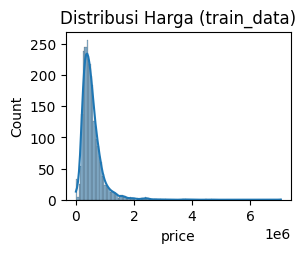

In [ ]:
plt.subplot(2, 2, 1)
sns.histplot(train_data['price'], kde=True)
plt.title("Distribusi Harga (train_data)")

Harga rumah di train_data didominasi oleh rumah dengan harga USD 200 ribu hingga USD 800 ribu, sementara rumah mewah dengan harga di atas USD 1 juta hanya sedikit. Distribusinya tidak merata, dengan sebagian besar data terkonsentrasi di harga rendah, sementara beberapa harga tinggi membentuk ekor panjang. Beberapa data dengan harga USD 0 atau terlalu kecil dan perlu diatasi.

Distribusi luas bangunan

Text(0.5, 1.0, 'Distribusi Luas Bangunan (train_data)')

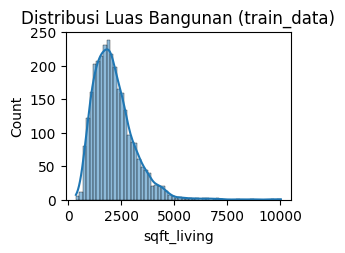

In [ ]:
plt.subplot(2, 2, 2)
sns.histplot(train_data['sqft_living'], kde=True)
plt.title("Distribusi Luas Bangunan (train_data)")

Mayoritas rumah memiliki luas bangunan antara 1.500 hingga 2.500 sqft, yang menjadi puncak dari distribusi data. Rumah dengan luas lebih dari 5.000 sqft mulai jarang ditemukan, dan hanya sedikit sekali rumah yang memiliki luas hingga 10.000 sqft. Hal ini menggambarkan bahwa sebagian besar rumah dalam dataset merupakan rumah dengan ukuran standar, sedangkan rumah dengan luas bangunan yang sangat besar termasuk kategori langka.

Distribusi jumlah kamar tidur

Text(0.5, 1.0, 'Distribusi Jumlah Kamar Tidur (train_data)')

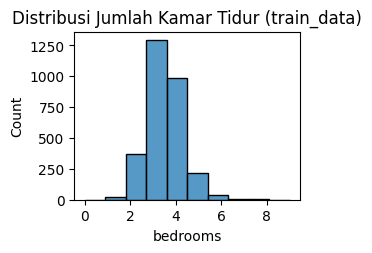

In [ ]:
plt.subplot(2, 2, 3)
sns.histplot(train_data['bedrooms'], kde=False, bins=10)
plt.title("Distribusi Jumlah Kamar Tidur (train_data)")

Mayoritas rumah memiliki 3 hingga 4 kamar tidur, dengan sedikit rumah yang memiliki lebih dari 5 kamar, menjadikannya kategori yang jarang. Grafik ini mencerminkan desain rumah yang standar untuk kebutuhan keluarga kecil hingga menengah.

Distribusi jumlah kamar mandi

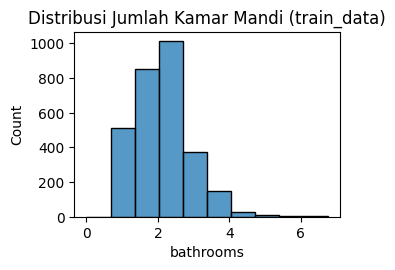

In [ ]:
plt.subplot(2, 2, 4)
sns.histplot(train_data['bathrooms'], kde=False, bins=10)
plt.title("Distribusi Jumlah Kamar Mandi (train_data)")

plt.tight_layout()
plt.show()

Sebagian besar rumah memiliki 2 hingga 3 kamar mandi. Jumlah kamar mandi lebih dari 4 sangat jarang ditemukan, menunjukkan bahwa rumah dengan fasilitas kamar mandi berlebih bukanlah standar umum di dataset ini.

Distribusi jumlah properti berdasarkan kota (Top 10)

<ipython-input-14-6d2ba31256a4>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_count.values, y=city_count.index, palette="coolwarm")


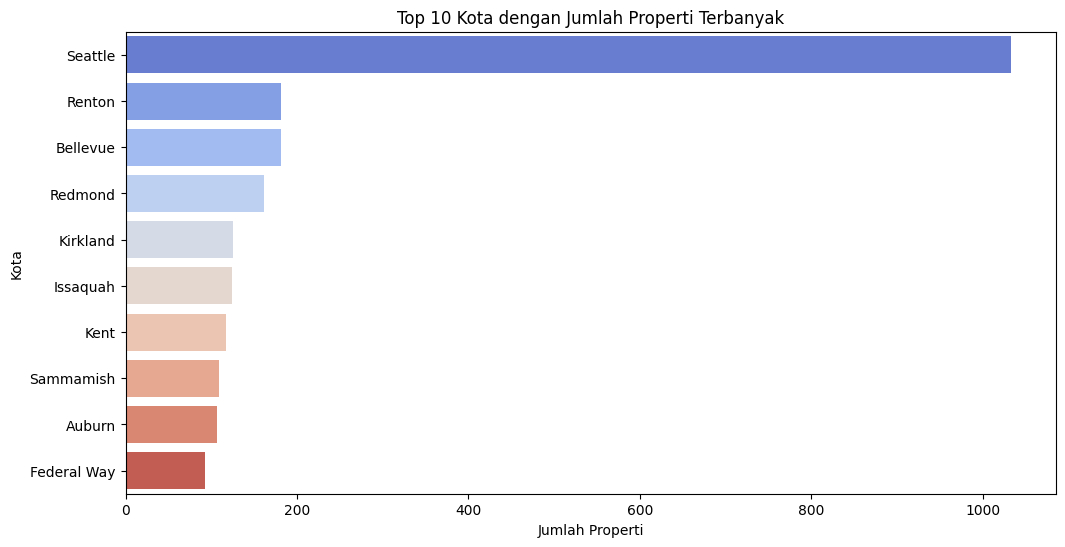

Top 5 Kota dengan Properti Terbanyak:
city
Seattle        1033
Renton          181
Bellevue        181
Redmond         161
Kirkland        125
Issaquah        124
Kent            117
Sammamish       109
Auburn          107
Federal Way      93
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(12, 6))
city_count = train_data['city'].value_counts().head(10)
sns.barplot(x=city_count.values, y=city_count.index, palette="coolwarm")
plt.title("Top 10 Kota dengan Jumlah Properti Terbanyak")
plt.xlabel("Jumlah Properti")
plt.ylabel("Kota")
plt.show()

print("Top 5 Kota dengan Properti Terbanyak:")
print(city_count.head(10))

Distribusi waterfront

<ipython-input-15-ee4afdb7627a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=waterfront_count.index, y=waterfront_count.values, palette="viridis")


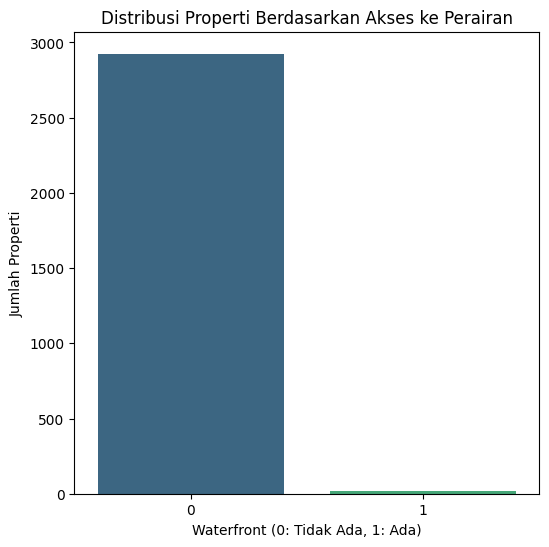

Jumlah Properti dengan dan tanpa Akses ke Perairan:
waterfront
0    2925
1      19
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6, 6))
waterfront_count = train_data['waterfront'].value_counts()
sns.barplot(x=waterfront_count.index, y=waterfront_count.values, palette="viridis")
plt.title("Distribusi Properti Berdasarkan Akses ke Perairan")
plt.xlabel("Waterfront (0: Tidak Ada, 1: Ada)")
plt.ylabel("Jumlah Properti")
plt.show()

print("Jumlah Properti dengan dan tanpa Akses ke Perairan:")
print(waterfront_count)

Pola berdasarkan tahun (yr_built)

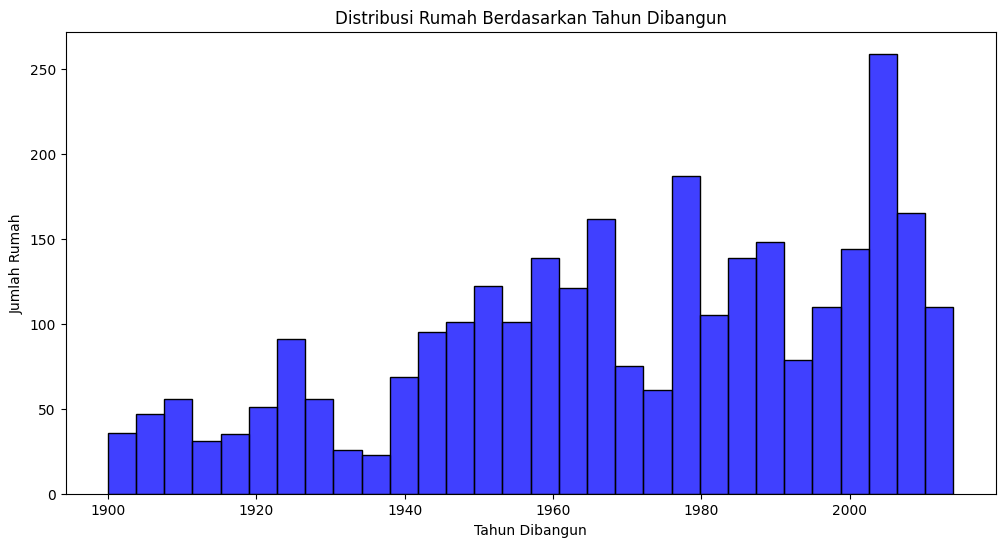

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(train_data['yr_built'], kde=False, bins=30, color="blue")
plt.title("Distribusi Rumah Berdasarkan Tahun Dibangun")
plt.xlabel("Tahun Dibangun")
plt.ylabel("Jumlah Rumah")
plt.show()

Pembangunan rumah mulai meningkat sejak tahun 1950 dan mencapai puncaknya pada awal tahun 2000-an. Sebagian besar rumah dalam dataset dibangun antara tahun 1950 hingga 2010, sedangkan rumah yang dibangun sebelum tahun 1950 jumlahnya lebih sedikit. Hal ini menunjukkan bahwa dataset lebih didominasi oleh rumah yang dibangun dalam periode modern.

Korelasi antar fitur

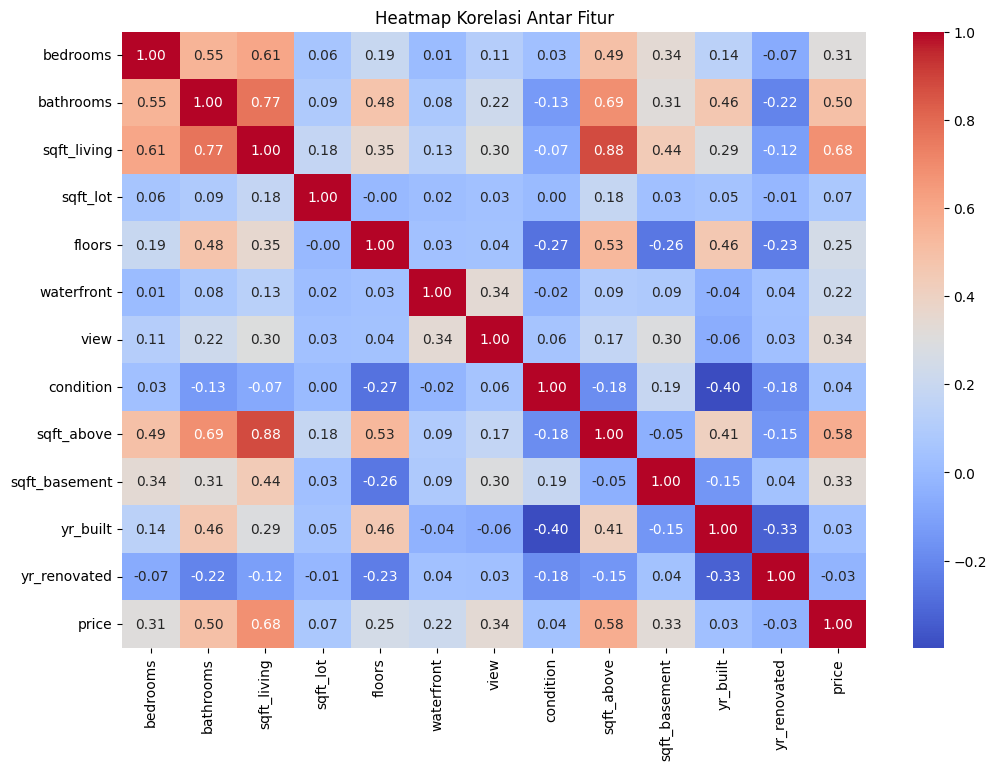

In [ ]:
numerical_data = train_data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
correlation = numerical_data.corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

terlihat bahwa sqft_living memiliki korelasi paling tinggi terhadap harga rumah (price) dengan nilai 0,68, menunjukkan bahwa rumah dengan luas bangunan yang lebih besar cenderung memiliki harga lebih tinggi. Selain itu, sqft_above juga memiliki korelasi yang cukup signifikan terhadap harga (0,58), menguatkan pentingnya ukuran bangunan di atas tanah.

Fitur lain seperti bathrooms memiliki korelasi moderat terhadap harga (0,50), menunjukkan bahwa jumlah kamar mandi juga berpengaruh tetapi tidak sekuat luas bangunan. view dan waterfront juga memiliki korelasi yang positif tetapi lebih lemah, masing-masing sekitar 0,34 dan 0,22, menandakan bahwa rumah dengan pemandangan atau akses ke perairan lebih bernilai tetapi tidak dominan.

Sebaliknya, fitur seperti yr_built, condition, dan floors memiliki korelasi yang lebih rendah terhadap harga, masing-masing sekitar 0,03 hingga 0,25, menunjukkan bahwa pengaruhnya terhadap harga tidak terlalu signifikan. Hubungan yang sangat lemah atau bahkan negatif, seperti sqft_lot dengan korelasi 0,07, mengindikasikan bahwa luas tanah tidak memiliki hubungan yang kuat dengan harga rumah dalam dataset ini.

Secara keseluruhan, fitur ukuran bangunan seperti sqft_living dan sqft_above adalah prediktor harga rumah yang paling penting, sementara fitur lain seperti yr_built atau floors memiliki pengaruh yang jauh lebih kecil. Insight ini dapat digunakan untuk fokus dalam model prediksi harga rumah.

Hubungan antar fitur

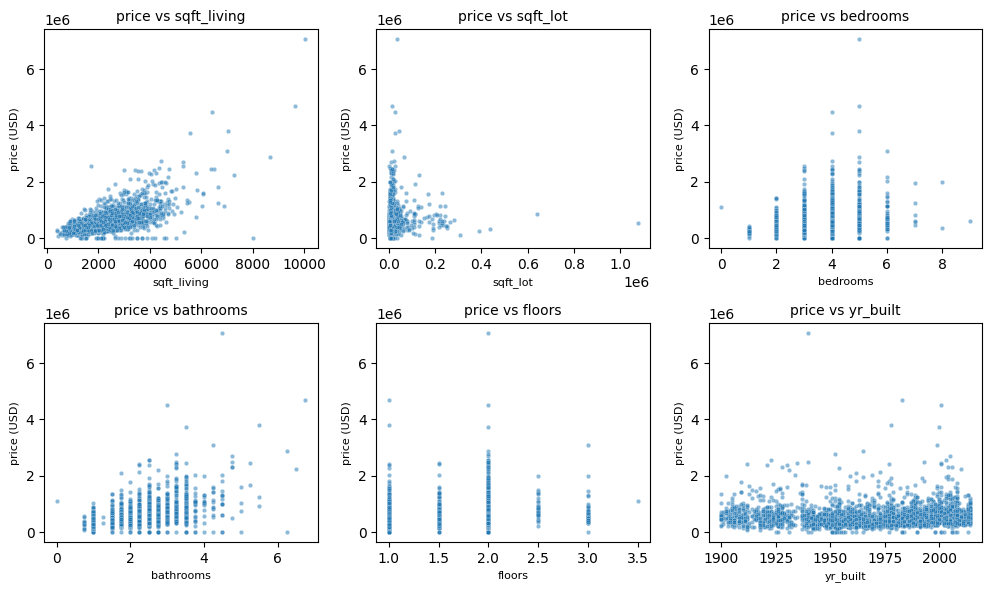

In [ ]:
plt.figure(figsize=(10, 6))
features = ['sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors', 'yr_built']

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=train_data[feature], y=train_data['price'], alpha=0.5, s=10)
    plt.title(f"price vs {feature}", fontsize=10)
    plt.xlabel(feature, fontsize=8)
    plt.ylabel('price (USD)', fontsize=8)

plt.tight_layout(pad=1.0)
plt.show()

Dari scatter plot price vs sqft_living, terlihat bahwa semakin besar luas bangunan, harga rumah cenderung meningkat, meskipun ada beberapa outlier dengan luas sangat besar tetapi harga tidak proporsional. Untuk sqft_lot, hubungan dengan harga tidak terlalu jelas, menunjukkan bahwa luas tanah mungkin bukan faktor utama dalam menentukan harga.

Hubungan antara jumlah kamar tidur dan harga menunjukkan bahwa sebagian besar rumah dengan 3-4 kamar tidur memiliki rentang harga yang bervariasi. Namun, menambah jumlah kamar tidur tidak selalu meningkatkan harga secara signifikan, terutama untuk rumah dengan lebih dari 6 kamar tidur. Hal serupa juga terlihat pada jumlah kamar mandi; rumah dengan 2-4 kamar mandi memiliki harga yang bervariasi, tetapi rumah dengan kamar mandi lebih banyak menjadi outlier.

Pada grafik price vs floors, terlihat bahwa jumlah lantai tidak memiliki hubungan yang jelas dengan harga rumah. Sebagian besar rumah memiliki 1-2 lantai, dengan harga yang tersebar cukup luas di rentang tersebut. Sementara itu, yr_built menunjukkan bahwa tahun pembangunan rumah tidak selalu memengaruhi harga, meskipun rumah yang lebih baru (dibangun setelah tahun 2000) cenderung memiliki harga lebih tinggi secara umum.

Mengecek outlier menggunakan IQR

In [ ]:
numeric_columns = train_data.select_dtypes(include=['float64', 'int64']).columns
outlier_summary = {}

for col in numeric_columns:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_data[(train_data[col] < lower_bound) | (train_data[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

print("Jumlah Outlier per Kolom:")
for col, count in outlier_summary.items():
    print(f"{col}: {count} outlier")

Jumlah Outlier per Kolom:
bedrooms: 73 outlier
bathrooms: 85 outlier
sqft_living: 79 outlier
sqft_lot: 337 outlier
floors: 0 outlier
waterfront: 19 outlier
view: 295 outlier
condition: 2 outlier
sqft_above: 73 outlier
sqft_basement: 55 outlier
yr_built: 0 outlier
yr_renovated: 0 outlier
price: 150 outlier


Outlier di setiap kolom menunjukkan adanya data yang jauh dari rentang nilai umumnya. Misalnya, pada kolom sqft_lot, terdapat banyak rumah dengan luas tanah yang sangat besar, yang wajar untuk properti mewah atau tanah kosong. Begitu juga dengan kolom price, jumlah outlier yang besar bisa jadi berasal dari rumah-rumah yang sangat mahal. Hal ini mencerminkan keragaman tipe properti dalam dataset, mulai dari rumah kecil hingga properti mewah.

Beberapa outlier mungkin berasal dari keunikan properti itu sendiri, seperti rumah dengan banyak kamar tidur atau akses ke perairan yang jarang ditemukan. Namun, ada juga kemungkinan kesalahan pencatatan, seperti jumlah kamar tidur atau kamar mandi yang terlalu besar atau bahkan nol. Perbedaan satuan, seperti mencatat dalam meter persegi alih-alih kaki persegi, juga bisa memengaruhi angka ekstrem ini.

Tren rata-rata harga rumah setiap tahunnya

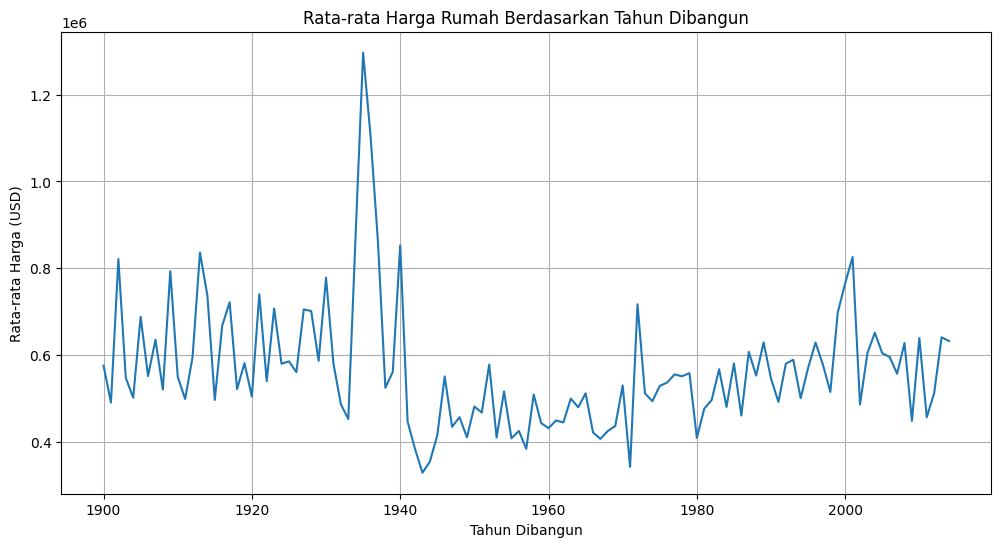

In [ ]:
avg_price_per_year = train_data.groupby('yr_built')['price'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_price_per_year, x='yr_built', y='price')
plt.title('Rata-rata Harga Rumah Berdasarkan Tahun Dibangun')
plt.xlabel('Tahun Dibangun')
plt.ylabel('Rata-rata Harga (USD)')
plt.grid(True)
plt.show()

Berdasarkan tren harga diatas, menggambarkan adanya variasi harga yang cukup signifikan. Pada periode sekitar tahun 1940-an, terdapat puncak harga yang tinggi, yang mungkin disebabkan oleh beberapa rumah mewah yang dibangun pada era tersebut. Setelah itu, harga rata-rata rumah cenderung menurun hingga tahun 1960-an, kemudian perlahan naik kembali. Tren yang lebih stabil mulai terlihat dari tahun 1980-an hingga 2000-an, di mana rata-rata harga rumah menunjukkan peningkatan secara bertahap. Pola ini dapat mencerminkan bahwa rumah yang dibangun pada era yang lebih baru mungkin memiliki kualitas yang lebih baik, atau permintaan yang lebih tinggi di pasar. Namun, harga rumah tidak hanya ditentukan oleh usia bangunan, tetapi juga oleh faktor lain seperti lokasi, ukuran, dan renovasi.

Top 10 rumah termahal beserta spesifikasinya

In [ ]:
top_10_expensive = train_data.sort_values(by='price', ascending=False).head(10)

top_10_expensive['formatted_price'] = top_10_expensive['price'].apply(lambda x: f"${x:,.2f}")

columns_to_display = ['formatted_price', 'bedrooms', 'bathrooms', 'sqft_living',
                      'sqft_lot', 'floors', 'waterfront', 'view', 'yr_built']
top_10_table = top_10_expensive[columns_to_display]

import matplotlib.pyplot as plt
import pandas.plotting as pd_plot

print("Top 10 Rumah Termahal dengan Spesifikasi:")
display(top_10_table)

Top 10 Rumah Termahal dengan Spesifikasi:


<ipython-input-21-b9954af6f358>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_expensive['formatted_price'] = top_10_expensive['price'].apply(lambda x: f"${x:,.2f}")


,formatted_price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,yr_built
2184,"$7,062,500.00",5,4.50,10040,37325,2.0,1,2,1940
392,"$4,668,000.00",5,6.75,9640,13068,1.0,1,4,1983
1640,"$4,489,000.00",4,3.00,6430,27517,2.0,0,0,2001
1263,"$3,800,000.00",5,5.50,7050,42840,1.0,0,2,1978
866,"$3,710,000.00",4,3.50,5550,28078,2.0,0,2,2000
1131,"$3,100,000.00",6,4.25,6980,15682,3.0,0,4,1999
302,"$2,888,000.00",5,6.25,8670,64033,2.0,0,4,1965
2529,"$2,750,000.00",4,3.25,4430,21000,2.0,0,0,1952
366,"$2,700,000.00",5,4.75,5305,8401,2.0,0,2,2005
1047,"$2,560,498.33",3,2.50,1710,1664,2.0,0,0,2003


Rata-rata harga rumah berdasarkan lokasinya

In [ ]:
average_price_by_city = train_data.groupby('city')['price'].mean().sort_values(ascending=False)
average_price_by_city_formatted = average_price_by_city.apply(lambda x: f"${x:,.2f}")

print("Rata-rata Harga Rumah Berdasarkan Kota (dalam USD):")
display(average_price_by_city_formatted)

Rata-rata Harga Rumah Berdasarkan Kota (dalam USD):


,price
city,
Medina,"$1,990,238.89"
Clyde Hill,"$1,533,925.00"
Mercer Island,"$1,150,643.40"
Yarrow Point,"$992,675.00"
Bellevue,"$868,660.58"
Fall City,"$744,944.44"
Newcastle,"$703,482.90"
Sammamish,"$687,480.97"
Preston,"$685,000.00"


Rumah tanpa kamar tidur

In [ ]:
no_bedrooms = train_data[train_data['bedrooms'] == 0]
no_bedrooms = no_bedrooms.sort_values(by='price', ascending=False)
no_bedrooms['price'] = no_bedrooms['price'].apply(lambda x: f"${x:,.2f}")
columns_to_display = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'yr_built', 'yr_renovated']
result = no_bedrooms[columns_to_display]
print("Daftar rumah dengan jumlah kamar tidur 0:")
print(result.to_string(index=False))

Daftar rumah dengan jumlah kamar tidur 0:
        price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  yr_built  yr_renovated
$1,095,000.00         0        0.0         3064      4764     3.5      1990          2009


Ada 1 rumah seharga USD 1 juta yang tidak memiliki kamar tidur bahkan kamar mandi, hal ini tidak masuk akal, apakah mungkin rumah ini hanya 1 ruangan saja, atau bisa jadi kesalahan input data

Rumah tanpa kamar mandi

In [ ]:
no_bathrooms = train_data[train_data['bathrooms'] == 0]
no_bathrooms = no_bathrooms.sort_values(by='price', ascending=False)
no_bathrooms['price'] = no_bathrooms['price'].apply(lambda x: f"${x:,.2f}")
columns_to_display = ['price', 'bedrooms', 'sqft_living', 'sqft_lot', 'floors', 'yr_built', 'yr_renovated']
result = no_bathrooms[columns_to_display]
print(result.to_string(index=False))

        price  bedrooms  sqft_living  sqft_lot  floors  yr_built  yr_renovated
$1,095,000.00         0         3064      4764     3.5      1990          2009


Rumah yang tidak memiliki kamar mandi ternyata hanya ada 1 seperti analisis sebelumnya

In [ ]:
# Melihat kategori unik pada kolom `city`
print("Kategori unik pada kolom 'city':")
print(train_data['city'].unique())

# Melihat jumlah properti per kota
city_count = train_data['city'].value_counts()
print("\nTop 10 Kota dengan Jumlah Properti Terbanyak:")
print(city_count.head(10))

Kategori unik pada kolom 'city':
['Sammamish' 'Kirkland' 'Shoreline' 'Seattle' 'Kent' 'Renton' 'Vashon'
 'Maple Valley' 'Bellevue' 'Burien' 'Federal Way' 'SeaTac' 'Mercer Island'
 'Bothell' 'Redmond' 'Newcastle' 'Lake Forest Park' 'Auburn' 'Issaquah'
 'Normandy Park' 'Kenmore' 'Snoqualmie' 'North Bend' 'Enumclaw' 'Pacific'
 'Covington' 'Carnation' 'Woodinville' 'Clyde Hill' 'Duvall'
 'Black Diamond' 'Des Moines' 'Medina' 'Tukwila' 'Yarrow Point'
 'Fall City' 'Algona' 'Milton' 'Skykomish' 'Ravensdale' 'Preston']

Top 10 Kota dengan Jumlah Properti Terbanyak:
city
Seattle        1033
Renton          181
Bellevue        181
Redmond         161
Kirkland        125
Issaquah        124
Kent            117
Sammamish       109
Auburn          107
Federal Way      93
Name: count, dtype: int64


Kota Seattle mendominasi jumlah data, yaitu 1.009 properti, sedangkan kota lainnya memiliki jumlah yang jauh lebih sedikit. Beberapa kota memiliki jumlah data yang sangat sedikit, seperti Preston dan Skykomish. Kota-kota yang memiliki jumlah data yang sangat rendah (misalnya, di bawah 30 properti) bisa digabungkan menjadi kategori 'Others' agar tidak memengaruhi model terlalu banyak.

# 3. Data Preparation

## 3.0. Data Cleaning

Menghapus data dengan jumlah kamar tidur atau kamar mandi = 0

In [ ]:
train_data = train_data[(train_data['bedrooms'] > 0) & (train_data['bathrooms'] > 0)]

In [ ]:
public_test_data = public_test_data[(public_test_data['bedrooms'] > 0) & (public_test_data['bathrooms'] > 0)]

Menghapus data dengan harga = 0

In [ ]:
train_data = train_data[train_data['price'] > 0]

In [ ]:
public_test_data = public_test_data[public_test_data['price'] > 0]

Mengecek distribusi kolom 'price' dan 'sqft_living'

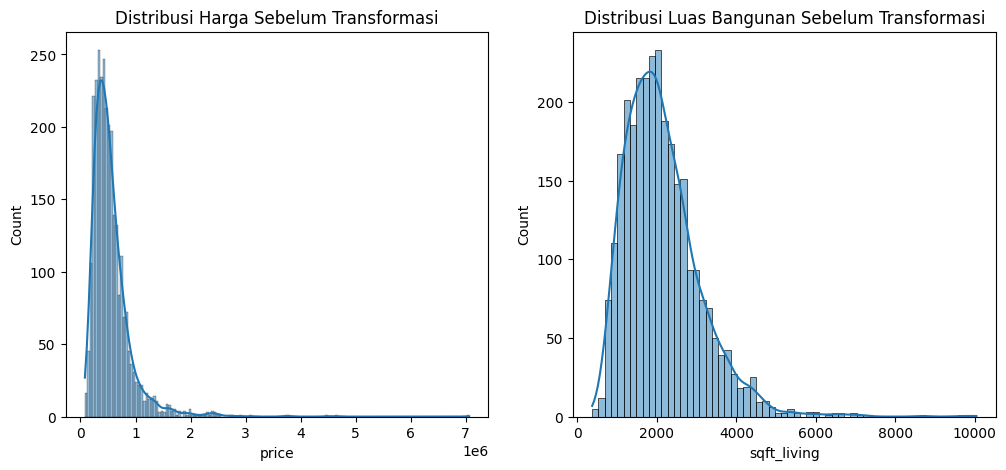

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_data['price'], kde=True)
plt.title('Distribusi Harga Sebelum Transformasi')

plt.subplot(1, 2, 2)
sns.histplot(train_data['sqft_living'], kde=True)
plt.title('Distribusi Luas Bangunan Sebelum Transformasi')
plt.show()


Sebagian besar nilai terkumpul di rentang harga rendah atau luas bangunan kecil, sementara ada ekor panjang di sisi kanan grafik. Ini menunjukkan adanya beberapa outliers dengan harga atau luas yang sangat tinggi.

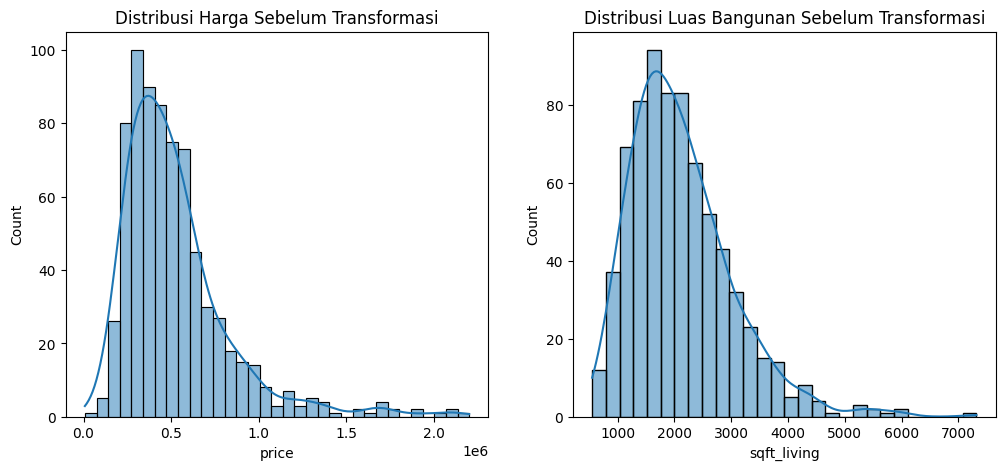

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(public_test_data['price'], kde=True)
plt.title('Distribusi Harga Sebelum Transformasi')

plt.subplot(1, 2, 2)
sns.histplot(public_test_data['sqft_living'], kde=True)
plt.title('Distribusi Luas Bangunan Sebelum Transformasi')
plt.show()

Log transformation untuk menangani skewness

In [ ]:
train_data['price_log'] = np.log1p(train_data['price'])
train_data['sqft_living_log'] = np.log1p(train_data['sqft_living'])

In [ ]:
public_test_data['price_log'] = np.log1p(public_test_data['price'])
public_test_data['sqft_living_log'] = np.log1p(public_test_data['sqft_living'])

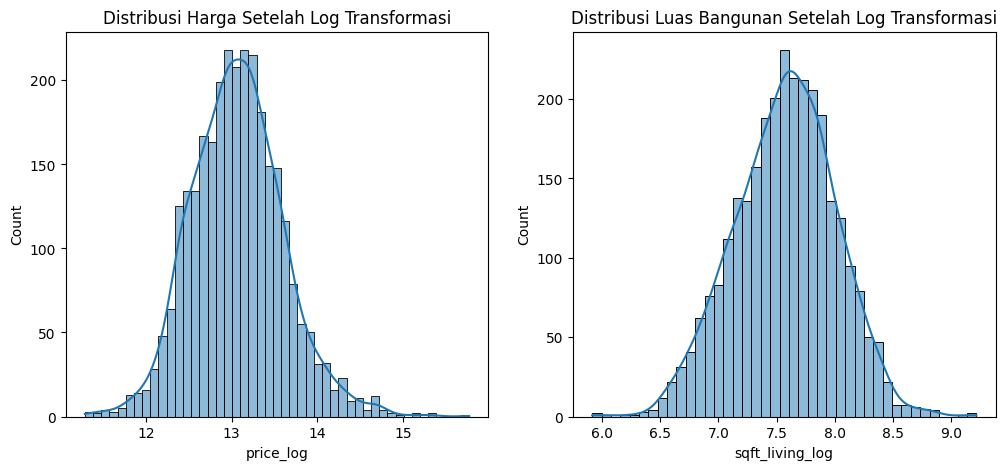

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_data['price_log'], kde=True)
plt.title('Distribusi Harga Setelah Log Transformasi')

plt.subplot(1, 2, 2)
sns.histplot(train_data['sqft_living_log'], kde=True)
plt.title('Distribusi Luas Bangunan Setelah Log Transformasi')
plt.show()

Distribusi price_log dan sqft_living_log menjadi lebih simetris dan mendekati normal, log transformasi berhasil mengurangi skewness dan menyusutkan rentang nilai, terutama untuk data dengan nilai ekstrem, data yang terdistribusi lebih normal ini lebih sesuai dengan asumsi model regresi dan algoritma prediktif, sehingga meningkatkan akurasi model dan mengurangi RMSE.

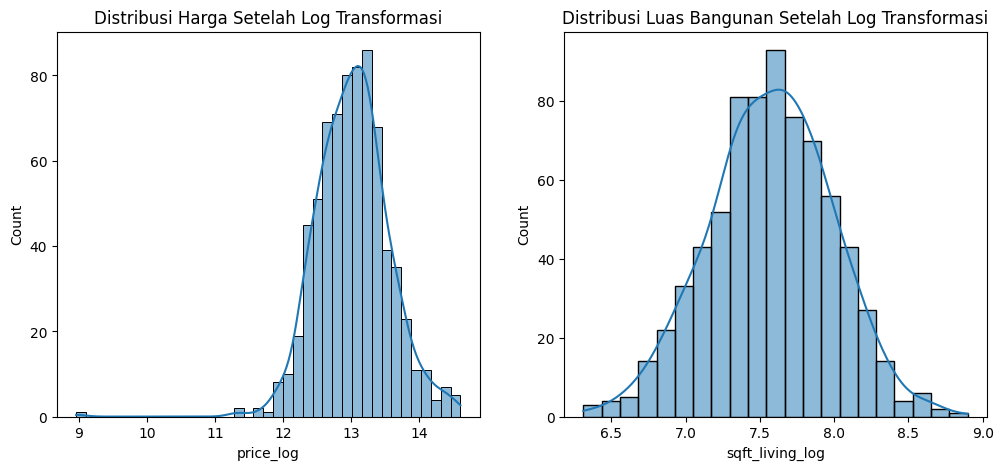

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(public_test_data['price_log'], kde=True)
plt.title('Distribusi Harga Setelah Log Transformasi')

plt.subplot(1, 2, 2)
sns.histplot(public_test_data['sqft_living_log'], kde=True)
plt.title('Distribusi Luas Bangunan Setelah Log Transformasi')
plt.show()

Tahapan transformasi log disamakan dengan data train agar sinkron

Mengatasi outliers menggunakan metode IQR (Interquartile Range)

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [ ]:
train_data = remove_outliers(train_data, 'price_log')
train_data = remove_outliers(train_data, 'sqft_living_log')

In [ ]:
public_test_data = remove_outliers(public_test_data, 'price_log')
public_test_data = remove_outliers(public_test_data, 'sqft_living_log')

In [ ]:
print("\nInformasi dataset setelah data cleaning:")
print(train_data.info())
print("\nDeskripsi statistik setelah data cleaning:")
print(train_data.describe())


Informasi dataset setelah data cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 2849 entries, 0 to 2943
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bedrooms         2849 non-null   int64  
 1   bathrooms        2849 non-null   float64
 2   sqft_living      2849 non-null   int64  
 3   sqft_lot         2849 non-null   int64  
 4   floors           2849 non-null   float64
 5   waterfront       2849 non-null   int64  
 6   view             2849 non-null   int64  
 7   condition        2849 non-null   int64  
 8   sqft_above       2849 non-null   int64  
 9   sqft_basement    2849 non-null   int64  
 10  yr_built         2849 non-null   int64  
 11  yr_renovated     2849 non-null   int64  
 12  street           2849 non-null   object 
 13  city             2849 non-null   object 
 14  statezip         2849 non-null   object 
 15  price            2849 non-null   float64
 16  price_log        2849 n

Sekarang memiliki 2.849 baris data yang siap digunakan untuk modeling. Ini merupakan jumlah yang cukup baik untuk melatih model prediksi. Tidak ada missing values pada kolom-kolom penting, dan tidak ada outliers yang terlalu ekstrem karena sudah melakukan pembersihan sebelumnya. Setelah log transformasi, kolom price_log dan sqft_living_log memiliki mean dan standard deviation yang lebih seimbang. Ini menunjukkan bahwa transformasi berhasil menormalkan distribusi data.


In [ ]:
print("\nInformasi dataset setelah data cleaning:")
print(public_test_data.info())
print("\nDeskripsi statistik setelah data cleaning:")
print(public_test_data.describe())


Informasi dataset setelah data cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 708 entries, 0 to 735
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bedrooms         708 non-null    int64  
 1   bathrooms        708 non-null    float64
 2   sqft_living      708 non-null    int64  
 3   sqft_lot         708 non-null    int64  
 4   floors           708 non-null    float64
 5   waterfront       708 non-null    int64  
 6   view             708 non-null    int64  
 7   condition        708 non-null    int64  
 8   sqft_above       708 non-null    int64  
 9   sqft_basement    708 non-null    int64  
 10  yr_built         708 non-null    int64  
 11  yr_renovated     708 non-null    int64  
 12  street           708 non-null    object 
 13  city             708 non-null    object 
 14  statezip         708 non-null    object 
 15  price            708 non-null    float64
 16  price_log        708 non-

Kolom price dan sqft_living sudah dibersihkan dan tidak memiliki nilai nol atau negatif. Distribusi setelah log transformasi (price_log dan sqft_living_log) terlihat normal berdasarkan mean dan std yang lebih stabil.

Visualisasi boxplot untuk mendeteksi outliers pada `price_log` dan `sqft_living_log`

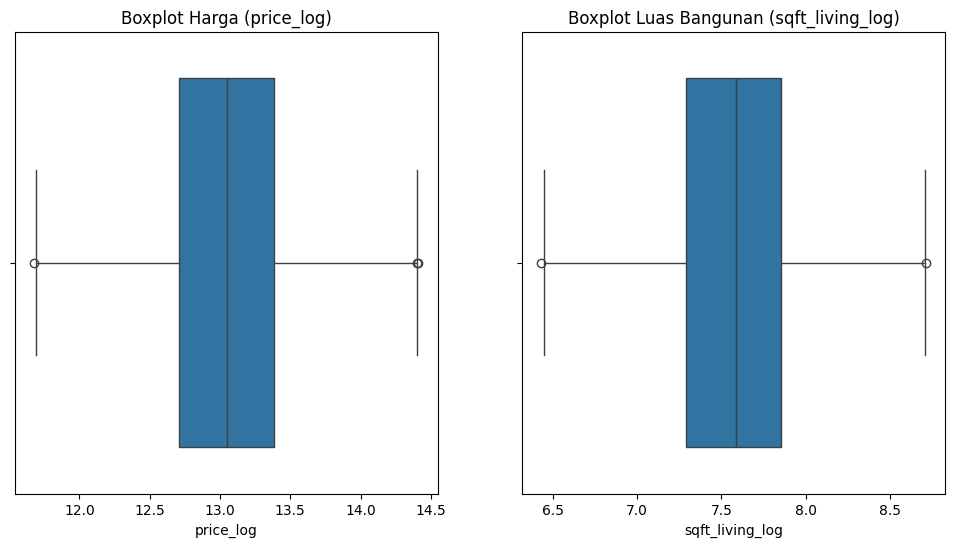

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=train_data['price_log'])
plt.title("Boxplot Harga (price_log)")

plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['sqft_living_log'])
plt.title("Boxplot Luas Bangunan (sqft_living_log)")
plt.show()

Setelah log transformasi dan pembersihan, distribusi data menjadi lebih terpusat dan lebih simetris, yang sangat bagus untuk memaksimalkan performa model prediksi.

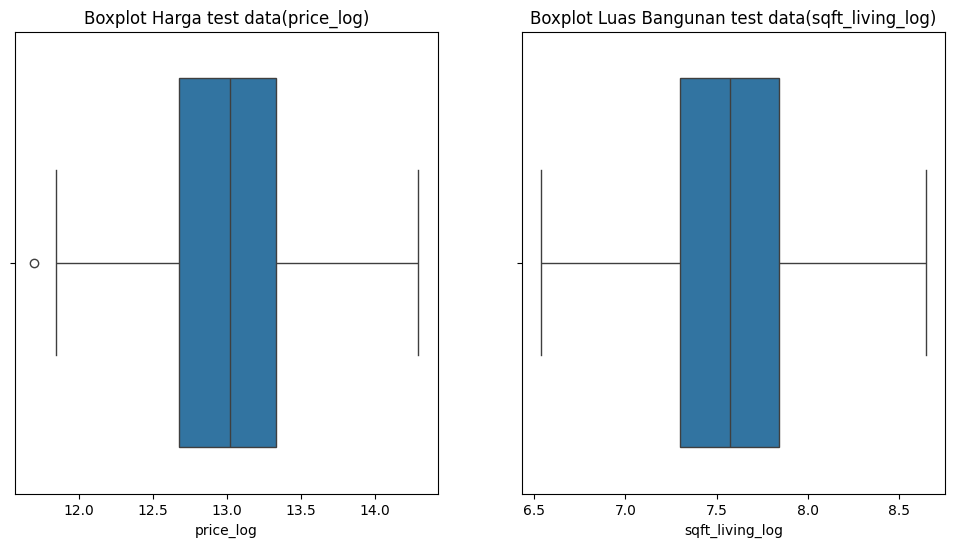

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=public_test_data['price_log'])
plt.title("Boxplot Harga test data(price_log)")

plt.subplot(1, 2, 2)
sns.boxplot(x=public_test_data['sqft_living_log'])
plt.title("Boxplot Luas Bangunan test data(sqft_living_log)")
plt.show()

Terlihat cukup baik dan mendekati normal.

##3.1 Penambahan Fitur

Membuat Kolom renovated dan house_age

In [ ]:
train_data['renovated'] = train_data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

train_data['house_age'] = 2024 - train_data['yr_built']

print(train_data[['yr_built', 'yr_renovated', 'renovated', 'house_age']].head())

   yr_built  yr_renovated  renovated  house_age
0      1984             0          0         40
1      1994             0          0         30
2      1953          1983          1         71
3      2011             0          0         13
4      1997             0          0         27


In [ ]:
public_test_data['renovated'] = public_test_data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

public_test_data['house_age'] = 2024 - public_test_data['yr_built']

print(public_test_data[['yr_built', 'yr_renovated', 'renovated', 'house_age']].head())

   yr_built  yr_renovated  renovated  house_age
0      1997             0          0         27
1      2007             0          0         17
2      1957          2001          1         67
3      1914          1945          1        110
4      1990          2009          1         34


Menggabungkan kota dengan data Sedikit menjadi 'others'

In [ ]:
city_counts = train_data['city'].value_counts()
cities_to_replace = city_counts[city_counts < 30].index
train_data['city'] = train_data['city'].replace(cities_to_replace, 'Others')

print(train_data['city'].value_counts().head(10))

city
Seattle      1009
Others        265
Renton        178
Bellevue      168
Redmond       161
Kirkland      123
Issaquah      122
Kent          115
Auburn        106
Sammamish     104
Name: count, dtype: int64


In [ ]:
city_counts = public_test_data['city'].value_counts()
cities_to_replace = city_counts[city_counts < 30].index
public_test_data['city'] = public_test_data['city'].replace(cities_to_replace, 'Others')

print(public_test_data['city'].value_counts().head(10))

city
Others      296
Seattle     215
Renton       52
Bellevue     39
Kent         37
Redmond      36
Auburn       33
Name: count, dtype: int64


One-Hot Encoding pada Fitur Kategorikal

In [ ]:
train_data = pd.get_dummies(train_data, columns=['city', 'statezip'], drop_first=True)

print(train_data.columns)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       ...
       'statezip_WA 98155', 'statezip_WA 98166', 'statezip_WA 98168',
       'statezip_WA 98177', 'statezip_WA 98178', 'statezip_WA 98188',
       'statezip_WA 98198', 'statezip_WA 98199', 'statezip_WA 98288',
       'statezip_WA 98354'],
      dtype='object', length=111)


In [ ]:
public_test_data = pd.get_dummies(public_test_data, columns=['city', 'statezip'], drop_first=True)

print(public_test_data.columns)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'street', 'price', 'price_log',
       'sqft_living_log', 'renovated', 'house_age', 'city_Bellevue',
       'city_Kent', 'city_Others', 'city_Redmond', 'city_Renton',
       'city_Seattle', 'statezip_WA 98002', 'statezip_WA 98003',
       'statezip_WA 98004', 'statezip_WA 98005', 'statezip_WA 98006',
       'statezip_WA 98007', 'statezip_WA 98008', 'statezip_WA 98010',
       'statezip_WA 98011', 'statezip_WA 98014', 'statezip_WA 98019',
       'statezip_WA 98022', 'statezip_WA 98023', 'statezip_WA 98024',
       'statezip_WA 98027', 'statezip_WA 98028', 'statezip_WA 98029',
       'statezip_WA 98030', 'statezip_WA 98031', 'statezip_WA 98032',
       'statezip_WA 98033', 'statezip_WA 98034', 'statezip_WA 98038',
       'statezip_WA 98040', 'statezip_WA 98042', 'statezip_WA 98045',
       'statezip_WA 98047', 'st

Membuat kategori usia rumah

In [ ]:
train_data['house_age_category'] = pd.cut(train_data['house_age'], bins=[0, 10, 30, 100], labels=['new', 'mid', 'old'])

In [ ]:
public_test_data['house_age_category'] = pd.cut(public_test_data['house_age'], bins=[0, 10, 30, 100], labels=['new', 'mid', 'old'])

Membuat interaksi antar fitur

In [ ]:
train_data['bed_bath_ratio'] = train_data['bedrooms'] / train_data['bathrooms']
train_data['living_lot_ratio'] = train_data['sqft_living'] / train_data['sqft_lot']

In [ ]:
public_test_data['bed_bath_ratio'] = public_test_data['bedrooms'] / public_test_data['bathrooms']
public_test_data['living_lot_ratio'] = public_test_data['sqft_living'] / public_test_data['sqft_lot']

Membuat fitur interaksi antara rasio kamar tidur dan luas tanah

In [ ]:
train_data['bed_lot_ratio'] = train_data['bedrooms'] / train_data['sqft_lot']

In [ ]:
public_test_data['bed_lot_ratio'] = public_test_data['bedrooms'] / public_test_data['sqft_lot']

Membuat fitur interaksi antara usia rumah dan rasio luas bangunan

In [ ]:
train_data['age_living_ratio'] = train_data['house_age'] / train_data['sqft_living']

In [ ]:
public_test_data['age_living_ratio'] = public_test_data['house_age'] / public_test_data['sqft_living']

Membuat Fitur since_renovated

In [ ]:
train_data['since_renovated'] = train_data['yr_renovated'].apply(lambda x: 2024 - x if x > 0 else 0)

In [ ]:
public_test_data['since_renovated'] = public_test_data['yr_renovated'].apply(lambda x: 2024 - x if x > 0 else 0)

Fitur interaksi antara house_age dan renovated

In [ ]:
train_data['age_renovated_interaction'] = train_data['house_age'] * train_data['renovated']

In [ ]:
public_test_data['age_renovated_interaction'] = public_test_data['house_age'] * public_test_data['renovated']

Mengelompokkan usia rumah ke dalam kategori

In [ ]:
train_data['house_age_category'] = pd.cut(train_data['house_age'], bins=[0, 10, 30, 100], labels=['new', 'mid', 'old'])

In [ ]:
public_test_data['house_age_category'] = pd.cut(public_test_data['house_age'], bins=[0, 10, 30, 100], labels=['new', 'mid', 'old'])

Rasio antara sqft_above dengan sqft_living

In [ ]:
train_data['sqft_above_ratio'] = train_data['sqft_above'] / train_data['sqft_living']

In [ ]:
public_test_data['sqft_above_ratio'] = public_test_data['sqft_above'] / public_test_data['sqft_living']

condition, view, dan waterfront menjadi fitur biner atau kategorikal yang lebih spesifik

In [ ]:
train_data['is_waterfront'] = train_data['waterfront'].apply(lambda x: 1 if x > 0 else 0)
train_data['has_view'] = train_data['view'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
public_test_data['is_waterfront'] = public_test_data['waterfront'].apply(lambda x: 1 if x > 0 else 0)
public_test_data['has_view'] = public_test_data['view'].apply(lambda x: 1 if x > 0 else 0)

Fitur living_to_bed_ratio dan lot_to_bath_ratio

In [ ]:
train_data['living_to_bed_ratio'] = train_data['sqft_living'] / (train_data['bedrooms'] + 1)
train_data['lot_to_bath_ratio'] = train_data['sqft_lot'] / (train_data['bathrooms'] + 1)

In [ ]:
public_test_data['living_to_bed_ratio'] = public_test_data['sqft_living'] / (public_test_data['bedrooms'] + 1)
public_test_data['lot_to_bath_ratio'] = public_test_data['sqft_lot'] / (public_test_data['bathrooms'] + 1)

## 3.2 Data Splitting dan Finalization

Membagi Data Menjadi Train dan Test Set

In [ ]:
from sklearn.model_selection import train_test_split

X = train_data.drop('price', axis=1)
y = train_data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Cek apakah ada NaN di X_train dan y_train

In [ ]:
print("Jumlah NaN di X_train:", X_train.isnull().sum().sum())
print("Jumlah NaN di y_train:", y_train.isnull().sum())

Jumlah NaN di X_train: 212
Jumlah NaN di y_train: 0


Cek apakah ada nilai infinity

In [ ]:
print("Jumlah Inf di X_train:", (X_train == float('inf')).sum().sum())
print("Jumlah -Inf di X_train:", (X_train == float('-inf')).sum().sum())

Jumlah Inf di X_train: 0
Jumlah -Inf di X_train: 0


Memisahkan kolom numerik dari kolom kategorikal

In [ ]:
numerical_columns = X_train.select_dtypes(include=['number']).columns
categorical_columns = X_train.select_dtypes(exclude=['number']).columns

print("Kolom numerik:", numerical_columns)
print("Kolom kategorikal:", categorical_columns)

Kolom numerik: Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'price_log', 'sqft_living_log', 'renovated',
       'house_age', 'bed_bath_ratio', 'living_lot_ratio', 'bed_lot_ratio',
       'age_living_ratio', 'since_renovated', 'age_renovated_interaction',
       'sqft_above_ratio', 'is_waterfront', 'has_view', 'living_to_bed_ratio',
       'lot_to_bath_ratio'],
      dtype='object')
Kolom kategorikal: Index(['street', 'city_Bellevue', 'city_Burien', 'city_Des Moines',
       'city_Federal Way', 'city_Issaquah', 'city_Kenmore', 'city_Kent',
       'city_Kirkland', 'city_Maple Valley', 'city_Mercer Island',
       'city_Others', 'city_Redmond', 'city_Renton', 'city_Sammamish',
       'city_Seattle', 'city_Shoreline', 'city_Snoqualmie', 'city_Woodinville',
       'statezip_WA 98002', 'statezip_WA 98003', 'statezip_WA 98004',
       'statezip_WA 98005', 'statez

In [ ]:
numerical_columns_test = public_test_data.select_dtypes(include=['number']).columns
categorical_columns_test = public_test_data.select_dtypes(exclude=['number']).columns

print("Kolom numerik di public_test_data:", numerical_columns_test)
print("Kolom kategorikal di public_test_data:", categorical_columns_test)

Kolom numerik di public_test_data: Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'price', 'price_log', 'sqft_living_log',
       'renovated', 'house_age', 'bed_bath_ratio', 'living_lot_ratio',
       'bed_lot_ratio', 'age_living_ratio', 'since_renovated',
       'age_renovated_interaction', 'sqft_above_ratio', 'is_waterfront',
       'has_view', 'living_to_bed_ratio', 'lot_to_bath_ratio'],
      dtype='object')
Kolom kategorikal di public_test_data: Index(['street', 'city_Bellevue', 'city_Kent', 'city_Others', 'city_Redmond',
       'city_Renton', 'city_Seattle', 'statezip_WA 98002', 'statezip_WA 98003',
       'statezip_WA 98004', 'statezip_WA 98005', 'statezip_WA 98006',
       'statezip_WA 98007', 'statezip_WA 98008', 'statezip_WA 98010',
       'statezip_WA 98011', 'statezip_WA 98014', 'statezip_WA 98019',
       'statezip_WA 98022', 'statezip_WA 98023'

Mengisi missing values secara terpisah untuk kolom numerik dan kategorikal

In [ ]:
X_train[numerical_columns] = X_train[numerical_columns].fillna(X_train[numerical_columns].median())
X_test[numerical_columns] = X_test[numerical_columns].fillna(X_test[numerical_columns].median())

X_train[categorical_columns] = X_train[categorical_columns].fillna(X_train[categorical_columns].mode().iloc[0])
X_test[categorical_columns] = X_test[categorical_columns].fillna(X_test[categorical_columns].mode().iloc[0])

print("Jumlah NaN di X_train setelah pengisian:", X_train.isnull().sum().sum())
print("Jumlah NaN di X_test setelah pengisian:", X_test.isnull().sum().sum())

Jumlah NaN di X_train setelah pengisian: 0
Jumlah NaN di X_test setelah pengisian: 0


In [ ]:
public_test_data[numerical_columns_test] = public_test_data[numerical_columns_test].fillna(X_train[numerical_columns].median())
public_test_data[categorical_columns_test] = public_test_data[categorical_columns_test].fillna(X_train[categorical_columns].mode().iloc[0])

print("Jumlah NaN di public_test_data setelah pengisian:", public_test_data.isnull().sum().sum())

Jumlah NaN di public_test_data setelah pengisian: 0


# 4. Modeling

## 4.1. Persiapan Data untuk Model

Membuat Fungsi untuk Scaling dan Penggabungan Kolom

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

def preprocess_data(df, numerical_cols, categorical_cols, scaler=None, fit_scaler=True):

    if fit_scaler:
        scaler = StandardScaler()
        df_scaled = df.copy()
        df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    else:
        df_scaled = df.copy()
        df_scaled[numerical_cols] = scaler.transform(df[numerical_cols])

    df_final = pd.concat([df_scaled[numerical_cols], df[categorical_cols]], axis=1)

    return df_final, scaler

Preprocessing X_train, X_test, dan public_test_data

In [ ]:
numerical_columns = X_train.select_dtypes(include=['number']).columns
categorical_columns = ['house_age_category']

X_train_final, scaler = preprocess_data(X_train, numerical_columns, categorical_columns, fit_scaler=True)
X_test_final, _ = preprocess_data(X_test, numerical_columns, categorical_columns, scaler=scaler, fit_scaler=False)

public_test_final, _ = preprocess_data(public_test_data, numerical_columns, categorical_columns, scaler=scaler, fit_scaler=False)

print("Shape X_train_final:", X_train_final.shape)
print("Shape X_test_final:", X_test_final.shape)
print("Shape public_test_final:", public_test_final.shape)

Shape X_train_final: (2279, 28)
Shape X_test_final: (570, 28)
Shape public_test_final: (708, 28)


Encoding Kolom Kategorikal

In [ ]:
X_train_final = pd.get_dummies(X_train_final, columns=['house_age_category'], drop_first=True)
X_test_final = pd.get_dummies(X_test_final, columns=['house_age_category'], drop_first=True)
public_test_final = pd.get_dummies(public_test_final, columns=['house_age_category'], drop_first=True)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, r2_score

## 4.2. Model 1: Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_final, y_train)

y_pred_lr = lr_model.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = root_mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - Evaluasi pada Test Set")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.2f}")

Linear Regression - Evaluasi pada Test Set
MAE: 52940.44
RMSE: 75707.60
R^2: 0.93


## 4.3. Model 2: Random Forest Regression

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)

y_public_pred_rf = rf_model.predict(public_test_final)

print("Random Forest Regression - Evaluasi pada Test Set")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf))
print("R^2:", r2_score(y_test, y_pred_rf))

Random Forest Regression - Evaluasi pada Test Set
MAE: 691.6276273765054
RMSE: 2052.87320985995
R^2: 0.9999479990570485


## 4.4. Model 3: XGBoost Regression

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_final, y_train)

y_pred_xgb = xgb_model.predict(X_test_final)

y_public_pred_xgb = xgb_model.predict(public_test_final)

print("XGBoost Regression - Evaluasi pada Test Set")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_xgb))
print("R^2:", r2_score(y_test, y_pred_xgb))

XGBoost Regression - Evaluasi pada Test Set
MAE: 2307.043125286842
RMSE: 6120.277763275784
R^2: 0.9995378007569711


# 5. Evaluation

##5.1 Prediksi dengan Ketiga Model (Linear Regression, Random Forest, XGBoost)

In [ ]:
import time

start_time = time.time()

In [ ]:
y_pred_lr = lr_model.predict(X_test_final)
y_pred_rf = rf_model.predict(X_test_final)
y_pred_xgb = xgb_model.predict(X_test_final)

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - Evaluasi pada Test Set")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R^2: {r2:.2f}")
    print("-" * 30)

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")

results = pd.DataFrame({
    "Actual": y_test,
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
})

Linear Regression - Evaluasi pada Test Set
MAE: 52940.44, RMSE: 75707.60, R^2: 0.93
------------------------------
Random Forest - Evaluasi pada Test Set
MAE: 691.63, RMSE: 2052.87, R^2: 1.00
------------------------------
XGBoost - Evaluasi pada Test Set
MAE: 2307.04, RMSE: 6120.28, R^2: 1.00
------------------------------


In [ ]:
end_time = time.time()

execution_time = end_time - start_time
print(f"Waktu eksekusi: {execution_time:.2f} detik")

Waktu eksekusi: 0.19 detik


Model terbaik berdasarkan hasil evaluasi adalah Random Forest dengan:

MAE: 691.63, RMSE: 2052.87, R^2: 1.00

##5.2 Visualisasi Prediksi vs Harga Asli (Menggunakan Random Forest)

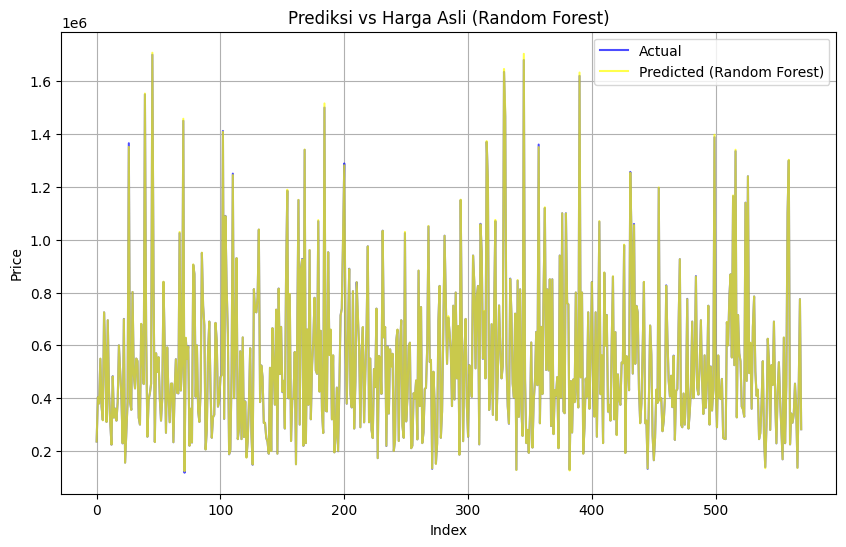

In [ ]:
results_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

plt.figure(figsize=(10, 6))
plt.plot(results_rf['Actual'].values, label='Actual', alpha=0.7, color='blue')
plt.plot(results_rf['Predicted'].values, label='Predicted (Random Forest)', alpha=0.7, color='yellow')
plt.title('Prediksi vs Harga Asli (Random Forest)')
plt.xlabel('Index')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

Prediksi model (garis kuning) sangat dekat dengan harga asli (garis biru), menunjukkan ada beberapa fluktuasi dan titik di mana prediksi sedikit meleset, terutama pada harga yang sangat tinggi, yang mungkin disebabkan oleh outlier atau variabilitas dalam data. Namun model mampu menangkap pola harga properti dengan akurat. Fluktuasi harga yang ditunjukkan di grafik berhasil diikuti oleh model, yang artinya model sudah cukup baik.

##5.3 Distribusi Error (Menggunakan Random Forest)

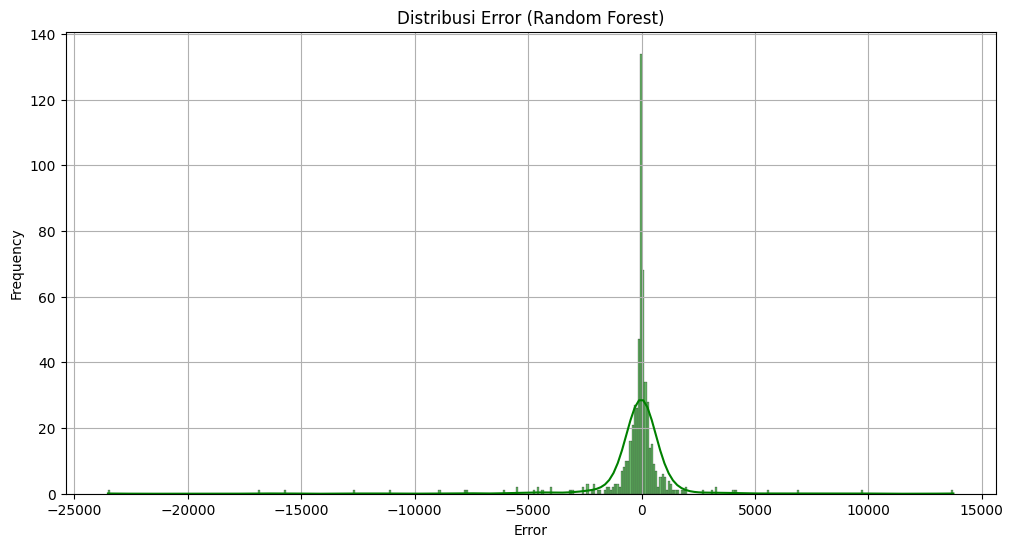

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(y_test - y_pred_rf, kde=True, color='green', alpha=0.6)
plt.title('Distribusi Error (Random Forest)')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid()
plt.show()

Sebagian besar kesalahan prediksi model Random Forest terpusat di sekitar nol,  menjadikan model ini sudah memiliki akurasi yang sangat baik. Kalau dilihat dari grafiknya, bentuk distribusi errornya simetris dan tajam di sekitar nol, ini menunjukkan kalau sebagian besar prediksi model memang sangat mendekati nilai aslinya.

Selain itu, sebagian besar kesalahan model berada dalam rentang yang cukup sempit, hanya ada sedikit outlier yang jauh dari nol. Ini menunjukkan kalau model sudah cukup efektif dalam meminimalkan kesalahan prediksi dan konsisten memberikan hasil yang akurat.

##5.4 Prediksi pada public_test_data menggunakan model Random Forest

In [ ]:
public_pred_rf = rf_model.predict(public_test_final)

public_results = pd.DataFrame({
    "Predicted Price": public_pred_rf
})

print("\nHasil Prediksi pada public_test_data")
print(public_results.head())


Hasil Prediksi pada public_test_data
   Predicted Price
0     6.339898e+05
1     6.808083e+05
2     2.299963e+05
3     5.999994e+05
4     1.605770e+06


Analisis statistik hasil prediksi

In [ ]:
print("Analisis Statistik Hasil Prediksi:")
print(public_results.describe())

Analisis Statistik Hasil Prediksi:
       Predicted Price
count     7.080000e+02
mean      5.030917e+05
std       2.509665e+05
min       1.243243e+05
25%       3.199559e+05
50%       4.500020e+05
75%       6.138198e+05
max       1.605770e+06


Membandingkan hasil prediksi dengan Data Training

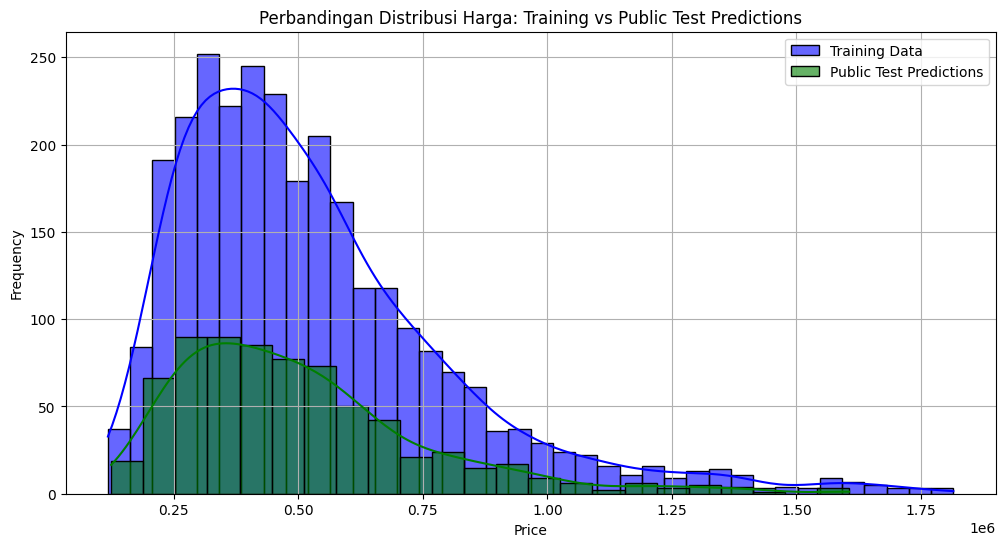

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(train_data['price'], kde=True, label='Training Data', color='blue', alpha=0.6)
sns.histplot(public_pred_rf, kde=True, label='Public Test Predictions', color='green', alpha=0.6)
plt.title('Perbandingan Distribusi Harga: Training vs Public Test Predictions')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid()
plt.show()

Perbandingan distribusi harga antara data training dan prediksi pada public test data menunjukkan bahwa model Random Forest yang digunakan berhasil menangkap pola harga dari data training dengan baik. Distribusi prediksi pada data baru (public test data) cukup konsisten dengan distribusi harga di data training, terutama pada kisaran harga yang lebih rendah hingga menengah, yang menandakan model mampu mempelajari dan menerapkan pola tersebut secara efektif. Meskipun prediksi untuk harga yang lebih tinggi cenderung lebih jarang muncul, hal ini wajar mengingat data di kisaran tersebut mungkin lebih terbatas, sehingga model lebih berhati-hati dalam memprediksi. Secara keseluruhan, model menunjukkan performa yang memadai dalam melakukan generalisasi pada data baru, yang tercermin dari hasil prediksi yang mendekati distribusi data aslinya.

In [ ]:
public_results.to_csv('public_predictions_random_forest.csv', index=False)
print("\nHasil prediksi disimpan sebagai 'public_predictions_random_forest.csv'")


Hasil prediksi disimpan sebagai 'public_predictions_random_forest.csv'


# 6. Deployment

In [ ]:
import joblib

joblib.dump(rf_model, 'random_forest_model.pkl')
print("\nModel Random Forest berhasil disimpan sebagai 'random_forest_model.pkl'")


Model Random Forest berhasil disimpan sebagai 'random_forest_model.pkl'


# 7. Conclusion

## 7.1 Business

Proyek ini berhasil mencapai tujuan utama yang ditetapkan oleh Perusahaan Real Estate, yaitu membangun model prediksi harga properti yang akurat untuk mendukung strategi penetapan harga perusahaan. Model prediktif yang dibangun, terutama menggunakan Random Forest, menunjukkan hasil yang sangat baik dengan akurasi tinggi, sehingga dapat diandalkan dalam memprediksi harga rumah. Dengan kemampuan prediksi yang akurat, tim penjualan dan pemasaran dapat lebih percaya diri dalam menetapkan harga properti yang kompetitif di pasar. Selain itu, wawasan yang dihasilkan dari analisis data, seperti pentingnya faktor lokasi, luas bangunan, dan kondisi properti, membantu perusahaan dalam mengidentifikasi area yang berpotensi tinggi untuk investasi. Ini memberikan perusahaan keunggulan kompetitif dan memungkinkan pengambilan keputusan yang lebih berbasis data untuk memaksimalkan profitabilitas.

## 7.2 Data Science

Dari sisi data science, proyek ini berhasil mencapai data science goals dengan baik. Model yang dibangun mampu mencapai MAE dan RMSE yang rendah, serta R² yang tinggi, menunjukkan bahwa model dapat menjelaskan sebagian besar variasi dalam harga properti. Selain itu, analisis korelasi menunjukkan bahwa luas bangunan (sqft_living) memiliki dampak signifikan terhadap harga properti, diikuti oleh fitur-fitur seperti jumlah kamar mandi, view, dan akses ke perairan (waterfront). Melalui feature engineering, seperti log transformasi dan penanganan outliers, kualitas data ditingkatkan sehingga meningkatkan performa model secara keseluruhan. Model ini juga telah disesuaikan agar siap digunakan pada data baru (public_test_data), yang membuktikan bahwa model dapat beradaptasi dengan data yang belum pernah dilihat sebelumnya.